<a href="https://colab.research.google.com/github/chrischristodoul/Data-Mining_Exercises/blob/main/PartA_Agdek.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Χριστοδουλου Χρηστος ΑΜ 5392**

**Ενότητα Α: Μετρητές Morris**


---



**Άσκηση 1**


---



**Α)**

---



Streaming output truncated to the last 5000 lines.
Iteration 995001: Estimate =1048575
Iteration 995002: Estimate =1048575
Iteration 995003: Estimate =1048575
Iteration 995004: Estimate =1048575
Iteration 995005: Estimate =1048575
Iteration 995006: Estimate =1048575
Iteration 995007: Estimate =1048575
Iteration 995008: Estimate =1048575
Iteration 995009: Estimate =1048575
Iteration 995010: Estimate =1048575
Iteration 995011: Estimate =1048575
Iteration 995012: Estimate =1048575
Iteration 995013: Estimate =1048575
Iteration 995014: Estimate =1048575
Iteration 995015: Estimate =1048575
Iteration 995016: Estimate =1048575
Iteration 995017: Estimate =1048575
Iteration 995018: Estimate =1048575
Iteration 995019: Estimate =1048575
Iteration 995020: Estimate =1048575
Iteration 995021: Estimate =1048575
Iteration 995022: Estimate =1048575
Iteration 995023: Estimate =1048575
Iteration 995024: Estimate =1048575
Iteration 995025: Estimate =1048575
Iteration 995026: Estimate =1048575
Iteration 995

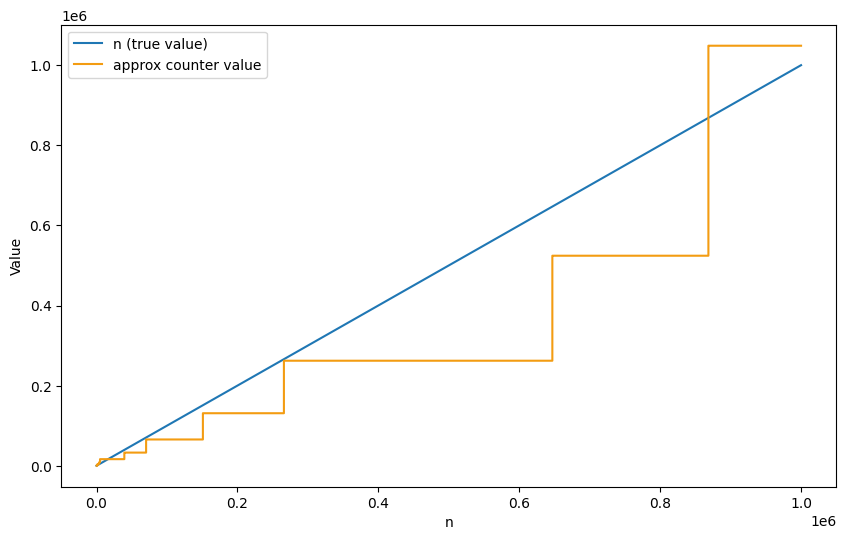

In [12]:
#libraries
import random
import matplotlib.pyplot as plt

random.seed(38)

#params
a=2
n_iter=1000000
count=0

def insert():
  global count
  prob = 1 / (a**count)
  if(random.random()<prob): #if cond-->true then increment-count
            count+=1

#return the estimate
def query():
  return (a**count)-1

#arrays for the values(i,out)
x_vals=[]
morris_vals=[]

for i in range(1,n_iter+1):
  insert()
  est=query()
  print(f"Iteration {i}: Estimate ={est}")
  if i%100==0:       #for every 100-data get the vals
    x_vals.append(i)
    morris_vals.append(est)

#plot
plt.figure(figsize=(10, 6))
plt.plot([0, n_iter], [0, n_iter], label='n (true value)', color='tab:blue')
plt.plot(x_vals, morris_vals, label='approx counter value', color='#f39c12', drawstyle='steps-post')
plt.xlabel('n')
plt.ylabel('Value')
plt.legend()
plt.show()


**Β)**

---



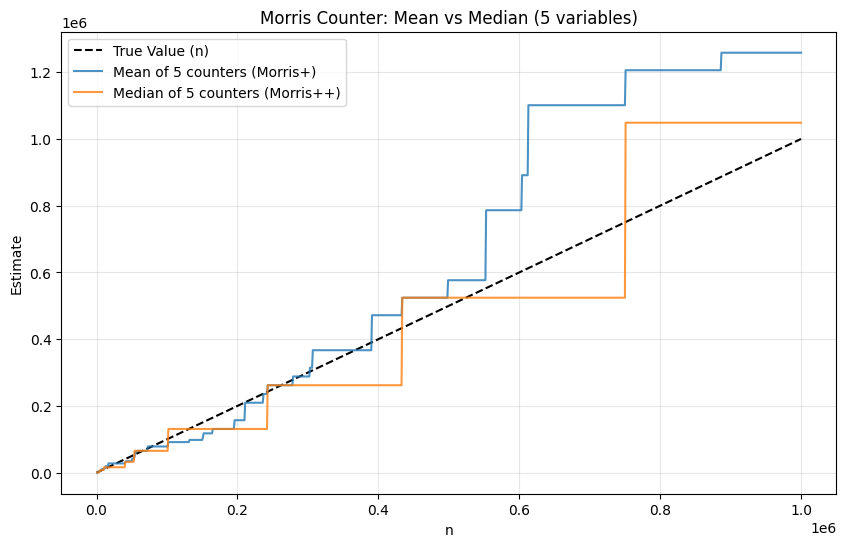

In [16]:
import random
import matplotlib.pyplot as plt
import statistics

#seed for to be the same
random.seed(52)

#params
a = 2
N_iter = 1000000
num_counters = 5
counters = [0] * num_counters  #list with [0,0,0,0,0]


def insert_multi():
    global counters
    for i in range(num_counters):
        #for every c if cond tru then count++
        prob = 1 / (a**counters[i])
        if random.random() < prob:
            counters[i] += 1

def query_mean():  #do the sum(est)/5

    estimates = [(a**c - 1) for c in counters]
    return sum(estimates) / len(estimates)

def query_median():  #get the median-sort is the 3-element
    estimates = [(a**c - 1) for c in counters]
    estimates.sort()
    return estimates[len(estimates)//2]

#data-holders
x_vals = []
mean_vals = []
median_vals = []

#run
for i in range(1, N_iter + 1):
    insert_multi()
    if i % 1000== 0:  #for every 1000-vals get the data
        x_vals.append(i)
        mean_vals.append(query_mean())
        median_vals.append(query_median())

#plot
plt.figure(figsize=(10, 6))
plt.plot([0, N_iter], [0, N_iter], color='black', linestyle='--', label='True Value (n)')
plt.plot(x_vals, mean_vals, label='Mean of 5 counters (Morris+)', alpha=0.8)
plt.plot(x_vals, median_vals, label='Median of 5 counters (Morris++)', alpha=0.8)

plt.title('Morris Counter: Mean vs Median (5 variables)')
plt.xlabel('n')
plt.ylabel('Estimate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()





**Συμπερασμα**

---
Συμπερασματικά, η διάμεσος (Morris) θεωρείται ανώτερη επιλογή από τον μέσο όρο, διότι είναι μια στιβαρή  στατιστική παράμετρος που αγνοεί τις ακραίες τιμές . Ενώ ο μέσος όρος μπορεί να παρασυρθεί εύκολα από έναν μόνο "τυχερό" μετρητή που εκτοξεύθηκε πρόωρα, η διάμεσος απαιτεί την "επιβεβαίωση" της πλειοψηφίας  για να αλλάξει επίπεδο.


**Γ)**

---

Ειναι ανουσιο να χρησιμοποιησουμε και βεβαια 5 μεταβλητες για ολο αυτο γιατι πρωτα απο ολα για ν=1.000.000 εισαγωγες ισχυει οτι   ⌈log2(⁡1.000.000) ⌉=20bⅈts για καθε μεταβλητη C αποθηκευεται στον εκθετη αρα ⌈lo2(⁡20) ⌉=5bⅈts.Αρα αν καθε μεταβλητη θελει χωρο οσο με 5μπιτς τοτε 5*5=25>20  που ειναι μεγαλυτερο απο οτι θελουμε.Για να ισχυουν θελουμε οτι 5*⌈log2⁡(log2⁡(n)) ⌉<⌈log2(⁡n) ⌉ οποτε βγαινει οτι n=2**25==33.500.000 εισαγωγες.

**Δ)**

---
Με 8 bits μνήμης, ο $C$ μπορεί να μετρήσει έως το 255. Αν θέταμε $\alpha=2$, η εκτίμηση για $C=255$ θα ήταν περίπου $2^{255}$, ένας αριθμός μεγαλύτερος από το $1.000.000$.Για $n=10^6$, ο μετρητής θα χρησιμοποιούσε μόνο τις πρώτες 20 τιμές. όσο το $\alpha$ πλησιάζει τη μονάδα,τόσο ο αλγόριθμος συμπεριφέρεται ως κανονικός μετρητής.Θέλουμε $$10^6 \approx \frac{\alpha^{255} - 1}{\alpha - 1}$$Λύνοντας την εξίσωση στο περίπου, προκύπτει ότι η βέλτιστη τιμή είναι $\alpha \approx 1.055$ αλλα θα δοκίμασουμε και αλλές τιμές.
Παρατήρουμε οτι για την α=1.02  φτανει αμεσως στο οριο και την υποεκτιμα  και πολύ μικρή αλλα και η α=1.1 ειναι παραπλησια αλλα την υποεκτιμα.


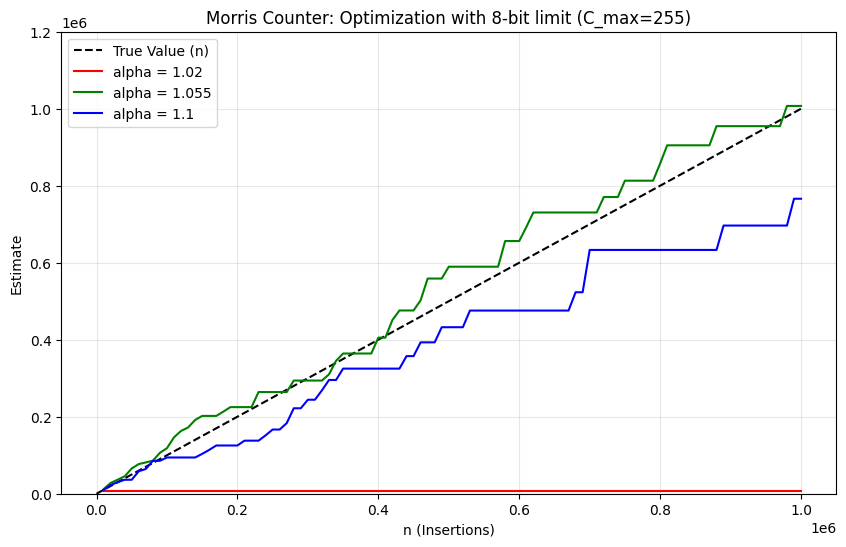

In [17]:
import random
import matplotlib.pyplot as plt

random.seed(42)

def run_morris_fixed_bits(alpha, n_max, bits=8):
    c = 0
    max_c = (2**bits) - 1 # 255 for 8 bits
    estimates = []

    for i in range(1, n_max + 1):
        # prpb to increment
        prob = 1 / (alpha**c)
        if random.random() < prob:
            if c < max_c:  #check not to pass the 8bit(255)
                c += 1

        #for every1-k get the estimation
        if i % 10000 == 0:
            est = (1/(alpha-1)) * (alpha**c - 1)
            estimates.append(est)

    return estimates

n_target = 1000000
#create x-axis
x_axis = list(range(10000, n_target + 1, 10000))

#try 3 a-vals
alphas = [1.02, 1.055, 1.1]
colors = ['red', 'green', 'blue']

#plot
plt.figure(figsize=(10, 6))
plt.plot([0, n_target], [0, n_target], 'k--', label='True Value (n)')

for a_val, col in zip(alphas, colors):
    results = run_morris_fixed_bits(a_val, n_target)  #call the func
    plt.plot(x_axis, results, label=f'alpha = {a_val}', color=col)

plt.title('Morris Counter: Optimization with 8-bit limit (C_max=255)')
plt.xlabel('n (Insertions)')
plt.ylabel('Estimate')
plt.ylim(0, n_target * 1.2)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Ε)**

---

Για τον δεύτερο αλγόριθμο, έχουμε 3 μετρητές των 5 bits ο καθένας. Αυτό σημαίνει $C_{max} = 2^5 - 1 = 31$.
Χρησιμοποιώντας τον τύπο $1.000.000 \approx \frac{\alpha^{31}-1}{\alpha-1}$, βρίσκουμε ότι το $\alpha \approx 1.55$ είναι μια καλή επιλογή

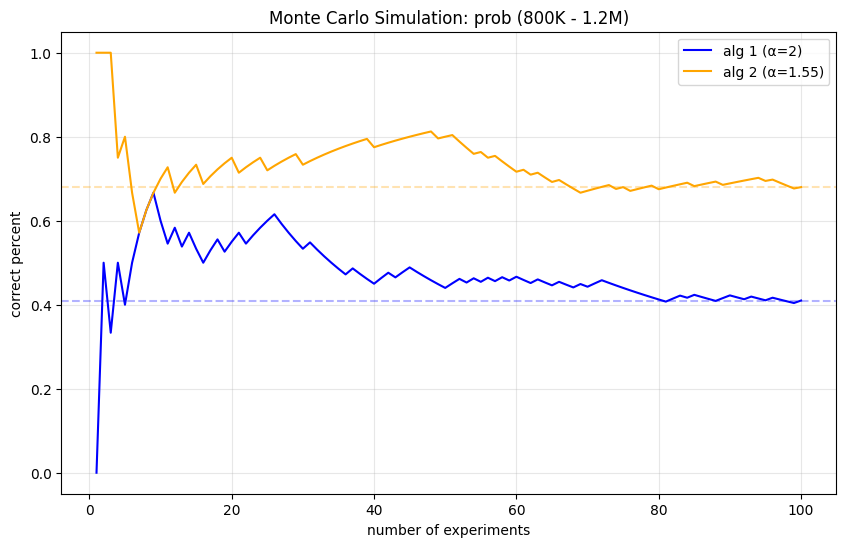

final prob Alg1: 0.41%
final prob Alg2: 0.68%


In [21]:
import random
import matplotlib.pyplot as plt

#params
N_INSERTS = 1000000
N_EXPERIMENTS = 100
LOWER_BOUND = 800000
UPPER_BOUND = 1200000

def morris_experiment(alpha, max_c):  #do the morris func
    c = 0
    for _ in range(N_INSERTS):
        if random.random() < (1 / (alpha**c)):
            if c < max_c:
                c += 1
    return (1/(alpha-1)) * (alpha**c - 1)

def run_monte_carlo():
  #hold data and the succeful-counter
    successes_alg1 = 0
    successes_alg2 = 0

    history_alg1 = []
    history_alg2 = []

    alpha2 = 1.55 # a val for second alg

    for i in range(1, N_EXPERIMENTS + 1):
        # algorith 1 Morris  α=2  max_c=32767
        est1 = morris_experiment(2.0, 32767)
        if LOWER_BOUND <= est1 <= UPPER_BOUND: #inside the cond then increment
            successes_alg1 += 1

        # Αλγόριθμος 2: mean-3-Morris α=1.55,  max_c=31
        est2_list = [morris_experiment(alpha2, 31) for _ in range(3)]  #call the morris for3 times
        avg_est2 = sum(est2_list) / 3 #calculate mean
        if LOWER_BOUND <= avg_est2 <= UPPER_BOUND:  #check the cond
            successes_alg2 += 1

        #get the probs for every run
        history_alg1.append(successes_alg1/i)
        history_alg2.append(successes_alg2/i)



    return history_alg1, history_alg2

#run
h1, h2 = run_monte_carlo()

#plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, N_EXPERIMENTS + 1), h1, label='alg 1 (α=2)', color='blue')
plt.plot(range(1, N_EXPERIMENTS + 1), h2, label='alg 2 (α=1.55)', color='orange')
plt.axhline(y=h1[-1], color='blue', linestyle='--', alpha=0.3)
plt.axhline(y=h2[-1], color='orange', linestyle='--', alpha=0.3)

plt.title('Monte Carlo Simulation: prob (800Κ - 1.2Μ)')
plt.xlabel('number of experiments')
plt.ylabel('correct percent')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"final prob Alg1: {h1[-1]:.2f}%")
print(f"final prob Alg2: {h2[-1]:.2f}%")

**Άσκηση 2**

---



**Α)**

---



for c=2: min-prob = 0.4218567224 στο n=511
for c=3: min-prob = 0.8049058495 στο n=10
for c=4: min-prob = 0.9177510591 στο n=509
for c=5: min-prob = 0.9647827148 στο n=6


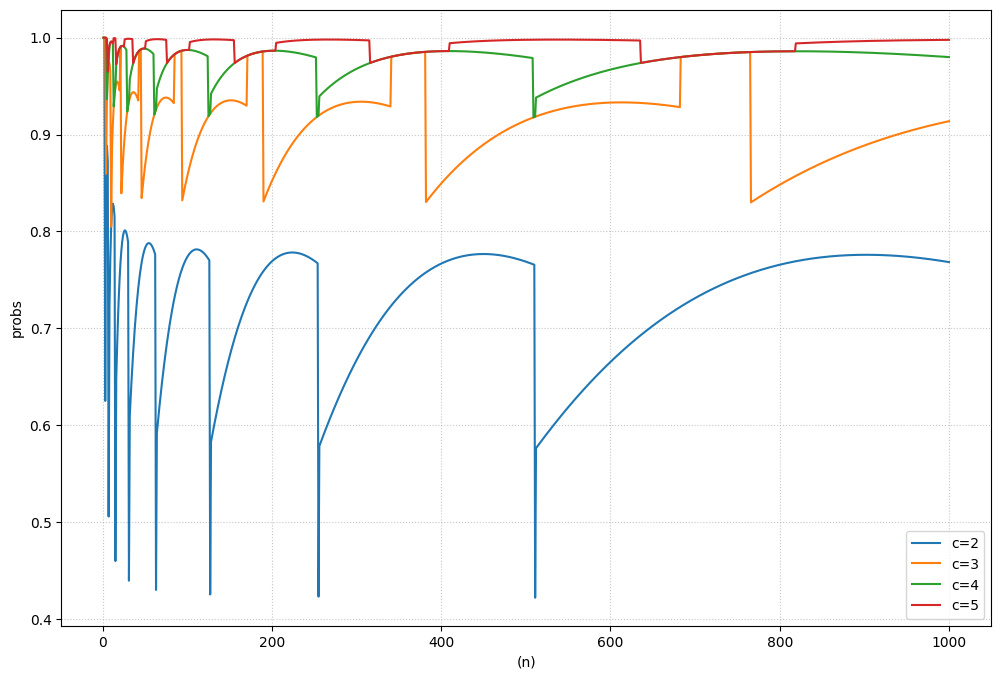

In [22]:
import matplotlib.pyplot as plt
from fractions import Fraction

def solve_morris_exact():
    max_n = 1000
    c_values = [2, 3, 4, 5]


    max_k = 15
    p = [Fraction(0)] * (max_k + 1)
    p[0] = Fraction(1)


    success_probs = {c: [] for c in c_values}
    min_probs = {c: (1.1, 0) for c in c_values}

    for n in range(1, max_n + 1):

        new_p = [Fraction(0)] * (max_k + 1)
        for k in range(max_k + 1):
            if p[k] == 0: continue

            prob_inc = Fraction(1, 2**k)
            #  k
            new_p[k] += p[k] * (1 - prob_inc)
            #  k+1
            if k + 1 <= max_k:
                new_p[k+1] += p[k] * prob_inc
        p = new_p

        #  P(n/c <= 2^k - 1 <= cn)  c
        for c in c_values:
            current_success = Fraction(0)
            for k in range(max_k + 1):
                estimate = 2**k - 1
                if (n / c) <= estimate <= (c * n):
                    current_success += p[k]

            prob_float = float(current_success)
            success_probs[c].append(prob_float)

            #min
            if prob_float < min_probs[c][0]:
                min_probs[c] = (prob_float, n)

    #plot
    plt.figure(figsize=(12, 8))
    for c in c_values:
        plt.plot(range(1, max_n + 1), success_probs[c], label=f'c={c}')
        print(f"for c={c}: min-prob = {min_probs[c][0]:.10f} στο n={min_probs[c][1]}")


    plt.xlabel('(n)')
    plt.ylabel('probs')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

solve_morris_exact()

**Β)**

---



In [25]:
def calculate_exact_probability(n_target, c_factor):
    # dp[k] = probability of being at counter value k and having stayed in bounds until now
    dp = {0: 1.0}

    for n in range(1, n_target + 1):
        new_dp = {}

        for k, prob in dp.items():
            # Probability of increment: 1 / 2^k
            p_inc = 1.0 / (2**k)

            # Case 1: Counter increments to k + 1
            k_next = k + 1
            est_next = (2**k_next) - 1
            if (n / c_factor) <= est_next <= (c_factor * n):
                new_dp[k_next] = new_dp.get(k_next, 0) + prob * p_inc

            # Case 2: Counter stays at k
            est_stay = (2**k) - 1
            if (n / c_factor) <= est_stay <= (c_factor * n):
                new_dp[k] = new_dp.get(k, 0) + prob * (1.0 - p_inc)

        dp = new_dp
        if not dp:
            return 0.0

    return sum(dp.values())

# Calculation for c = 2, 3, 4, 5
c_values = [2, 3, 4, 5]
results = {}

for c in c_values:
    res = calculate_exact_probability(1000, c)
    results[c] = res

# Output formatting

for c in c_values:
    print(f"{c:<5} | {results[c]:.10f}")

2     | 0.0038262996
3     | 0.2301353421
4     | 0.6048009394
5     | 0.8117779814


**Γ)**

---



In [26]:
from fractions import Fraction

def solve_morris_double():
    max_n = 1000
    c_values = [2, 3, 4, 5]
    max_bits = 15 # 4 bits max value


    probs = {0: Fraction(1, 1)}

    min_probabilities = {c: Fraction(1, 1) for c in c_values}

    for n in range(1, max_n + 1):

        new_probs = {}
        for x, p_x in probs.items():

            prob_inc = Fraction(1, 2**x) if x < max_bits else Fraction(0, 1)

            # X -> x + 1
            if x < max_bits:
                new_probs[x + 1] = new_probs.get(x + 1, 0) + p_x * prob_inc
            # X -> x
            new_probs[x] = new_probs.get(x, 0) + p_x * (1 - prob_inc)

        probs = new_probs


        for c in c_values:
            success_p = Fraction(0, 1)
            lower_bound = Fraction(n, c)
            upper_bound = n * c


            for x1, p1 in probs.items():
                for x2, p2 in probs.items():
                    #
                    est = Fraction((2**x1 - 1) + (2**x2 - 1), 2)

                    if lower_bound <= est <= upper_bound:
                        success_p += p1 * p2

            if success_p < min_probabilities[c]:
                min_probabilities[c] = success_p

    #
    for c in c_values:
        print(f"for c={c}, min-prob (Average of 2): {float(min_probabilities[c]):.10f}")

solve_morris_double()

for c=2, min-prob (Average of 2): 0.7653979040
for c=3, min-prob (Average of 2): 0.9626221636
for c=4, min-prob (Average of 2): 0.9939054352
for c=5, min-prob (Average of 2): 0.9989469051
